<a href="https://colab.research.google.com/github/grasht/projects_ML_HW_6/blob/main/HW6_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 2

**Comparing common sampling methods of diffusion models.**

We compare the following four sampling methods using a synthetic (artificial) target distribution:


*   **Predictor Only (Euler-Maruyama)**: A first-order numerical method for simulating the reser-time SDE. The sample is updated by the drift, which is given by the score model. Simplest aproach. Introduces discretization error.
*   **Predictor + MCMC Noise Corrector (Langevin)**: According to (Yang Song, et all), if you have a score based model you can use an MCMC approach to sample the distribution at a given time step directly and correct the predictor. This is the idea behind the Langevin method. It is a hybrid method that combines SDE stepping with Markov Chain Monte Carlo refinement. It reduces sampling error by nuding samples toward high-rpobablity regions using Lagevin dynamics. This helps to better match the target distribution at that time step.
*   **Predictor + Deterministic Corrector (Heun)**: A second-order improvement over Euler-Maruyama. It reduces the sdiscretization error without using MCM noise injection. Instead, it performs a predictor step, them re-evaluates the drift at the predicted point and takes the average of the two slipes, allowing for a more accurate update.
*   **Reverse Diffusion-Style Discretization:** This method discretizes the reverse-time SDE in way that matches the forward diffusion process. Each step combines the learned score-based drift and noise to provide a more accurate update.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
def log_prob(x):
  p1 = np.exp(-0.5 * (x+2)**2)
  p2 = np.exp(-0.5 * (x-2)**2)
  return np.log(0.5 * p1 + 0.5 * p2 + 1e-8)

def score(x):
  p1 = np.exp(-0.5 * (x+2)**2)
  p2 = np.exp(-0.5 * (x-2)**2)
  num = (x+2) * p1 - (x-2) * p2
  den = p1 + p2 + 1e-8 #avoid 0
  return num / den

#Predictor Only (Euler-Maruyama)

In [ ]:
def predictor_sampler(n_samples=1000, steps=100, dt=0.01):
    x = np.random.randn(n_samples) * 5  # start from noise
    for _ in range(steps):
        drift = score(x)
        noise = np.sqrt(dt) * np.random.randn(n_samples)
        x = x + drift * dt + noise
    return x

# P+C Langevin

In [ ]:
def lengevin_sampler(n_samples=1000, steps=100, dt=0.01, corrector_steps=5, eps=0.005):
    x = np.random.randn(n_samples) * 5
    for _ in range(steps):
        # Predictor step
        drift = score(x)
        x = x + drift * dt + np.sqrt(dt) * np.random.randn(n_samples)

        # Corrector (Langevin MCMC)
        for _ in range(corrector_steps):
            grad = score(x)
            noise = np.sqrt(2 * eps) * np.random.randn(n_samples)
            x = x + eps * grad + noise
    return x

#P+C Heun

In [ ]:
def heun_sampler(n_samples=1000, steps=100, dt=0.01):
    x = np.random.randn(n_samples) * 5

    for _ in range(steps):
        z = np.random.randn(n_samples)

        drift = score(x)
        x_pred = x + drift * dt + np.sqrt(dt) * z
        #Recompute Drift
        drift_pred = score(x_pred)
        #Heun correction (average drift)
        drift_avg = 0.5 * (drift + drift_pred)

        x = x + drift_avg * dt + np.sqrt(dt) * z

    return x

# Reverse Diffusion-Style Discretization

In [ ]:
def reverse_diffusion_sampler(n_samples=1000, steps=100):
    x = np.random.randn(n_samples) * 5
    betas = np.linspace(0.0001, 0.02, steps)

    for beta in betas:
        noise = np.random.randn(n_samples)
        x = x + beta * score(x) + np.sqrt(beta) * noise
    return x

# Results

In [ ]:
start = time.time()
samples_pred = predictor_sampler()
end = time.time()
print("Execution Time: ", end - start)

plt.hist(samples_pred, bins=100, alpha=0.4, label="Predictor", color="blue")

plt.legend()
plt.title("Predictor Sampler")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

**1,000 Samples**

Execution Time: 0.012379169464111328

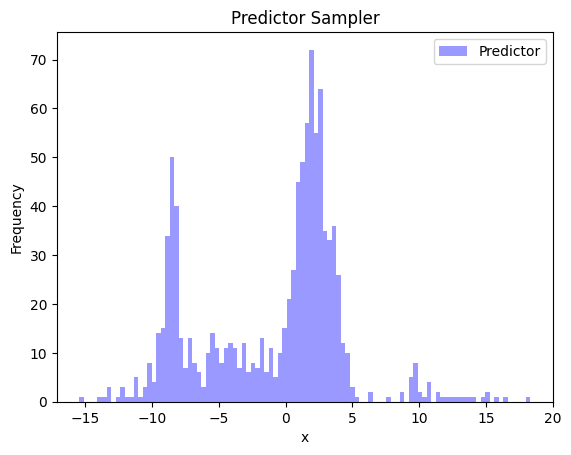

**10,000 Samples**

Execution Time:  0.06021428108215332

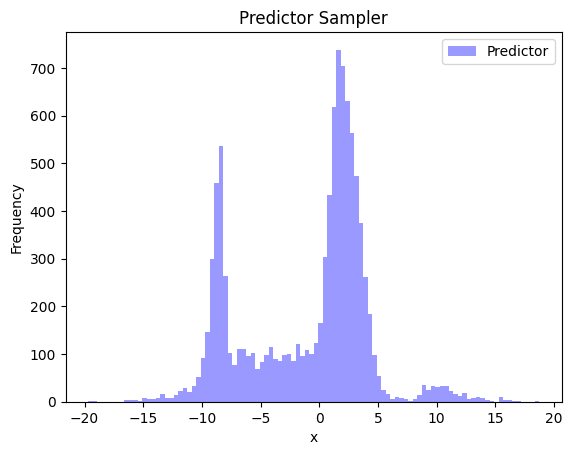

In [ ]:
start = time.time()
samples_pc = lengevin_sampler()
end = time.time()
print("Execution Time: ", end - start)

plt.hist(samples_pc, bins=100, alpha=0.4, label="Lengevin Sampler", color="green")


plt.legend()
plt.title("Langevin Sampler")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

**1,000 Samples**

Execution Time:  0.05457592010498047

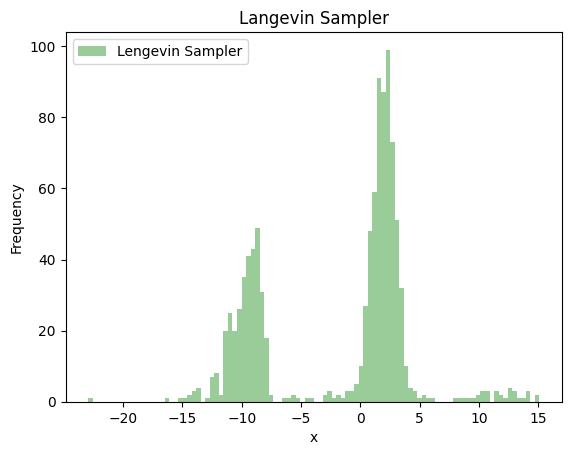

**10,000 Samples**

Execution Time:  0.37582945823669434



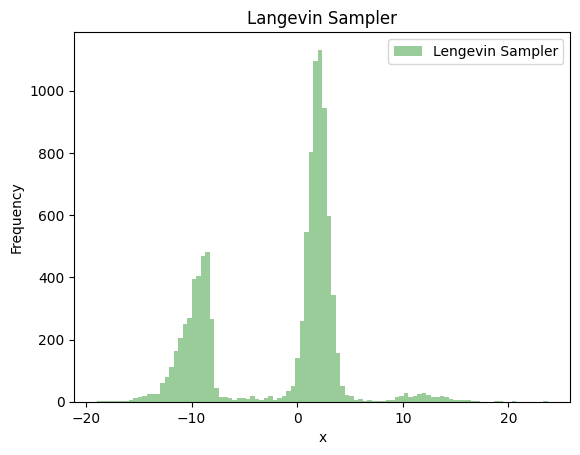

In [ ]:
start = time.time()
samples_adapt = heun_sampler()
end = time.time()
print("Execution Time: ", end - start)

plt.hist(samples_adapt, bins=100, alpha=0.4, label="Heun", color='red')

plt.legend()
plt.title("Heun Sampler")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

**1,000 Samples**

Execution Time:  0.016049861907958984

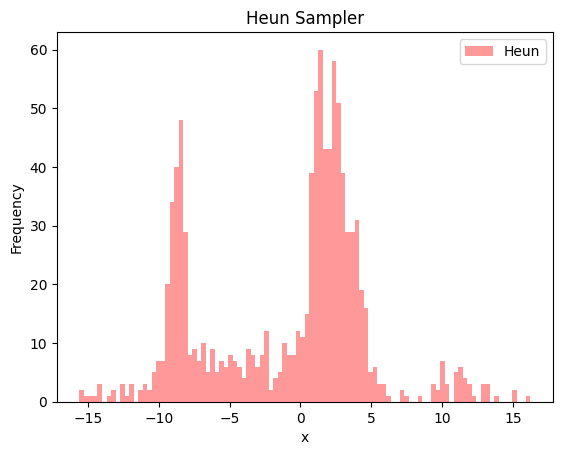

**10,000 Samples**

Execution Time:  0.09158778190612793

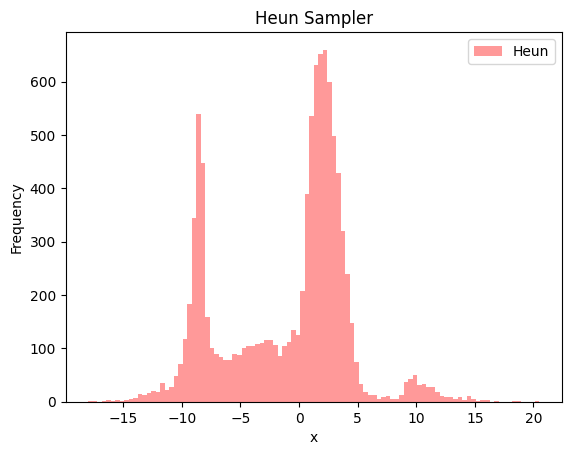

In [ ]:
start = time.time()
samples_rd = reverse_diffusion_sampler()
end = time.time()
print("Execution Time: ", end - start)

plt.hist(samples_rd, bins=100, alpha=0.4, label="Reverse Diffusion", color="orange")

plt.legend()
plt.title("Reverse Diffusion Sampler")
plt.xlabel("x")
plt.ylabel("Frequency")
plt.show()

**1,000 Samples**

Execution Time:  0.012847661972045898

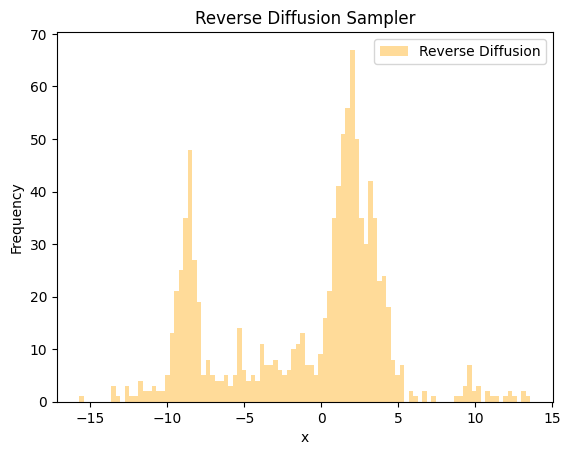

**10,000 Samples**

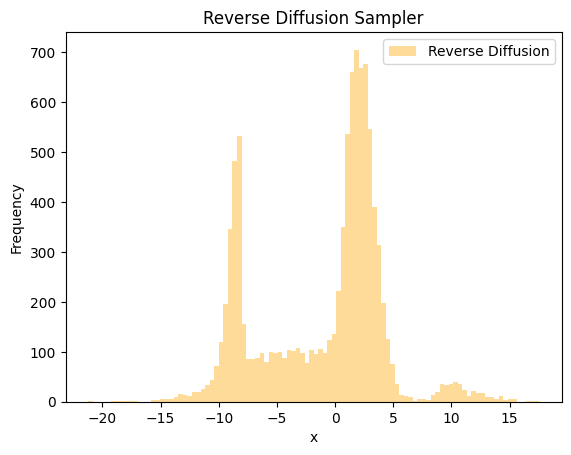

In [ ]:
plt.hist(samples_pred, bins=100, alpha=0.4, label="Predictor", color="blue")
plt.hist(samples_pc, bins=100, alpha=0.4, label="Langevin", color="green")
plt.hist(samples_adapt, bins=100, alpha=0.4, label="Heun", color="red")
plt.hist(samples_rd, bins=100, alpha=0.4, label="Reverse Diffusion", color="orange")
plt.legend(title="Methods")

**Comparison Graphs**


**1,000 Samples**

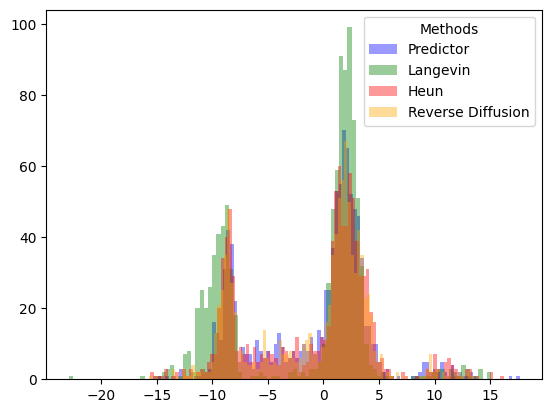

**10,000 Samples**

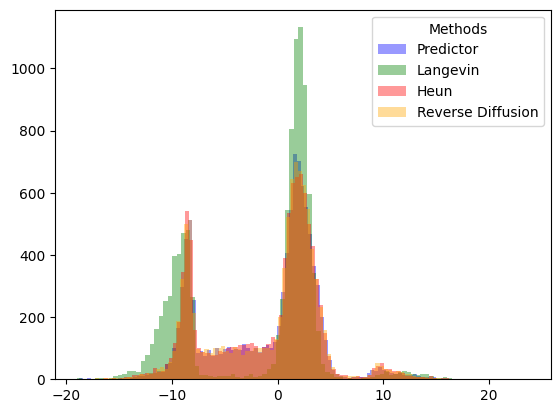

**Execution Time Ranking:**


1.   Predictor
2.   Reverse Diffusion
3.   Heun
4.   Lengevin

When jumping from 1,000 to 10,000 samples you can see the execution time differeces widen while the ranking remains the same. This highlights how the different methods scale in terms of efficiency.




# Conclusion

As expected, the frequency graphs show that all four methods generally follow the multi-modal distribution. The two peaks are roughly in the same spot for each graph. However, the Lengevin method shows the sharpest modes at both 1,000 and 10,000 samples. The other three methods performed similarly with Reverse Diffusion seeming to take perform second best at 10,000, but Heun performing second best at 1,000 samples. While Lengevin sampled the distribution the best, it was also the least efficeint method, so one of the other three are worth exploring more if efficeincy is more important than sample quality.

# Next Steps

This expirement focused solely on the sampling procedures used in diffusion models. From here I would look for a problem area. That is a dataset that needs generated sampels. I would develop/pick a neural network training pipeline and apply it to learn from the dataset associated with my problem area. I would then apply these samplers to the model to generate samples. Then you could compare the results and see if the results of this simplified experiment hold true for generating real and ideally more complex data distributions.

# Risks and Challenges

Discretization error - Introduced by the fact we are using finite step sizes to approximate a continuous true process. Errors accumulate as steps do, meaning there may be challenges at scale. In extreme cases this can lead to artifacts or oversmoothing.

The score function assumption - We assume that we have a known score function. In practice, we have to learn this function using an AI model. This can introduce issues such as mode collapse or loss of diversity. This may also result in over generalization, or samples that drift away from the expected regions.



# Sources and Inspiration
Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021). Score-Based Generative Modeling through Stochastic Differential Equations. arXiv [Cs.LG]. Retrieved from http://arxiv.org/abs/2011.13456

Yang, L., Zhang, Z., Song, Y., Hong, S., Xu, R., Zhao, Y., … Yang, M.-H. (2023). Diffusion Models: A Comprehensive Survey of Methods and Applications. ACM Comput. Surv., 56(4). doi:10.1145/3626235

https://stable-diffusion-art.com/samplers/

https://www.deviantart.com/aipythondev/journal/Stable-Diffusion-17-Sampling-Methods-Comparison-1105865341